# Notebook 1 - Exploratory Data Analysis

This notebook covers the full EDA pipeline for the **Web Page Topic Classification**.

**Dataset:** 1050 HTML documents across 7 page-type categories: `FAQ`, `accueil`, `blog`, `commerce`, `home`, `liste`, `recherche`
- Train split: 840 docs (120 per class)
- Test split: 210 docs (30 per class)

**Goals:**
1. Load and parse raw HTML files via BeautifulSoup
2. Extract text content and structural HTML features
3. Analyze class distributions, text lengths, vocabulary
4. Save processed data for downstream notebooks

In [15]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')

TRAIN_DIR = '../data/raw/train'
TEST_DIR  = '../data/raw/test'
OUT_DIR   = '../data'

CLASSES = ['FAQ','accueil','blog','commerce','home','liste','recherche']
PALETTE = ['#7c6aff','#ff6a9e','#6affd4','#ffd06a','#ff9d6a','#6ab8ff','#d46aff']

plt.rcParams.update({
    # Backgrounds
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',

    # Fonts and Text
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': '#333333',
    'axes.labelcolor': '#333333',

    # Axes and Spines
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,

    # Ticks
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'xtick.bottom': True,
    'ytick.left': False,

    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#eeeeee',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
})

## 1. HTML Parsing & Feature Extraction

Each file is parsed with BeautifulSoup. We extract:
- **Text content** (scripts/styles stripped)
- **Structural signals**: link count, images, form inputs, tables, headings, list items

In [3]:
def parse_html(filepath):
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        raw = f.read()
    soup = BeautifulSoup(raw)
    for tag in soup(['script','style','meta','link']):
        tag.decompose()
    text = re.sub(r'\s+', ' ', soup.get_text(separator=' ', strip=True)).strip()
    return {
        'text': text, 'text_len': len(text), 'n_words': len(text.split()),
        'title': soup.title.string.strip() if soup.title and soup.title.string else '',
        'n_links': len(soup.find_all('a')),
        'n_forms': len(soup.find_all('form')),
        'n_inputs': len(soup.find_all('input')),
        'n_tables': len(soup.find_all('table')),
        'n_imgs': len(soup.find_all('img')),
        'n_headings': sum(len(soup.find_all(f'h{i}')) for i in range(1,7)),
        'n_list_items': len(soup.find_all('li')),
        'n_paragraphs': len(soup.find_all('p')),
    }

def load_dataset(root_dir, split_name):
    records = []
    for label in sorted(os.listdir(root_dir)):
        folder = os.path.join(root_dir, label)
        if not os.path.isdir(folder): continue
        for fname in os.listdir(folder):
            try:
                feats = parse_html(os.path.join(folder, fname))
                feats.update({'label': label, 'file': fname, 'split': split_name})
                records.append(feats)
            except Exception as e:
                print(f'  Error: {fname}: {e}')
    return pd.DataFrame(records)

train_df = load_dataset(TRAIN_DIR, 'train')
test_df  = load_dataset(TEST_DIR,  'test')
print(f'Train: {len(train_df)} | Test: {len(test_df)}')
train_df.head(3)

Train: 840 | Test: 210


,text,text_len,n_words,title,n_links,n_forms,n_inputs,n_tables,n_imgs,n_headings,n_list_items,n_paragraphs,label,file,split
0,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLO...",2383,377,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLONES",31,1,4,5,23,0,0,8,FAQ,faq00000000000000001.htm,train
1,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLO...",3202,506,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLONES",32,1,4,5,23,0,8,13,FAQ,faq00000000000000002.htm,train
2,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLO...",5493,925,"FAQ : HURRICANES, TYPHOONS, AND TROPICAL CYCLONES",32,1,4,5,24,0,0,12,FAQ,faq00000000000000003.htm,train


## 2. Dataset Overview

In [4]:
print('Train distribution:')
print(train_df['label'].value_counts())
print('\nTest distribution:')
print(test_df['label'].value_counts())
print('\nStructural feature summary:')
struct_cols = ['n_links','n_forms','n_inputs','n_tables','n_imgs','n_headings','n_list_items']
train_df[struct_cols + ['text_len']].describe().round(1)

Train distribution:
label
FAQ          120
accueil      120
blog         120
commerce     120
home         120
liste        120
recherche    120
Name: count, dtype: int64

Test distribution:
label
FAQ          30
accueil      30
blog         30
commerce     30
home         30
liste        30
recherche    30
Name: count, dtype: int64

Structural feature summary:


,n_links,n_forms,n_inputs,n_tables,n_imgs,n_headings,n_list_items,text_len
count,840.0,840.0,840.0,840.0,840.0,840.0,840.0,840.0
mean,93.5,1.3,7.7,13.1,45.6,3.7,16.4,6525.0
std,152.4,2.0,19.1,17.8,104.1,10.4,70.3,12666.4
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0
25%,27.0,0.0,0.0,1.0,6.0,0.0,0.0,1280.2
50%,57.5,1.0,4.0,6.0,20.0,0.0,0.0,2973.5
75%,126.0,2.0,7.0,18.0,35.0,2.0,6.0,6396.5
max,3249.0,30.0,452.0,115.0,1665.0,162.0,1459.0,124614.0


## 3. Class Distribution

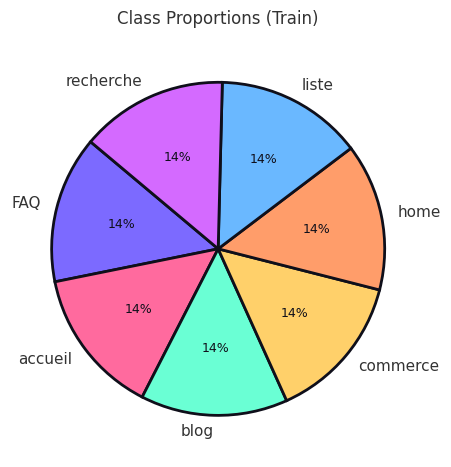

In [18]:
counts = [train_df['label'].value_counts()[c] for c in CLASSES]

wedges, texts, autotexts = plt.pie(counts, labels=CLASSES, colors=PALETTE,
    autopct='%1.0f%%', startangle=140, wedgeprops={'linewidth':2,'edgecolor':'#0f0f1a'})
for at in autotexts: at.set_color('#0f0f1a'); at.set_fontsize(9)
plt.title('Class Proportions (Train)', fontsize=12, pad=12)

plt.tight_layout()
plt.show()

## 4. Text Length Analysis

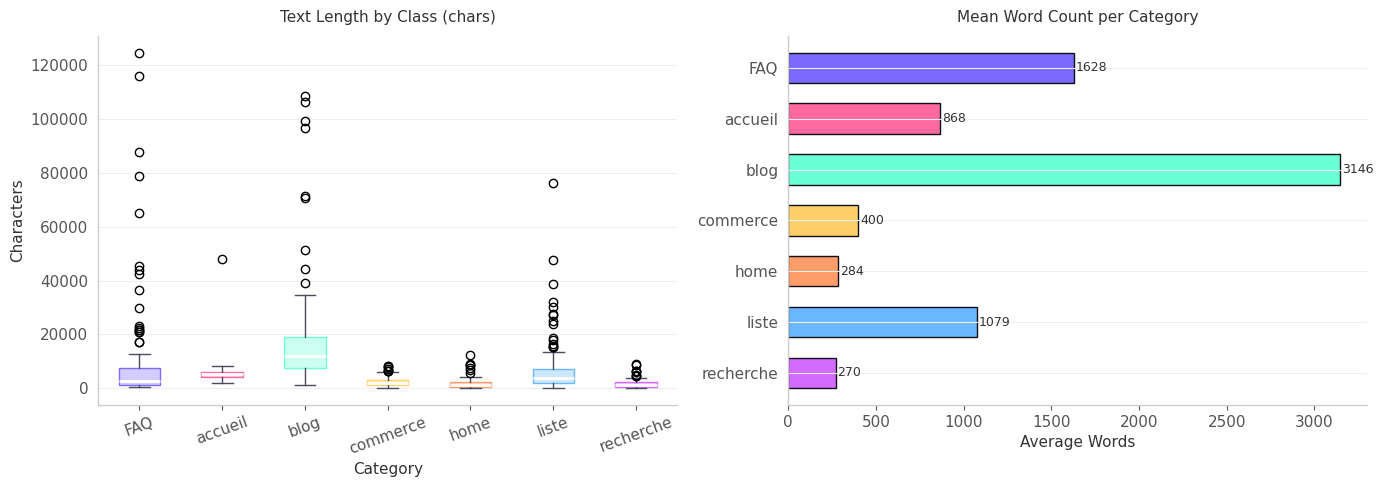

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_per_class = [train_df[train_df['label']==c]['text_len'].values for c in CLASSES]
bp = axes[0].boxplot(data_per_class, labels=CLASSES, patch_artist=True,
                     medianprops={'color':'#fff','linewidth':2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color+'55'); patch.set_edgecolor(color)
for w in bp['whiskers']: w.set_color('#4a4a60')
for c in bp['caps']: c.set_color('#4a4a60')
axes[0].set_title('Text Length by Class (chars)', fontsize=11, pad=10)
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Characters')
axes[0].tick_params(axis='x', rotation=20)

mean_words = [train_df[train_df['label']==c]['n_words'].mean() for c in CLASSES]
bars = axes[1].barh(CLASSES, mean_words, color=PALETTE, edgecolor='#0f0f1a', height=0.6)
for bar, val in zip(bars, mean_words):
    axes[1].text(val+10, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)
axes[1].set_title('Mean Word Count per Category', fontsize=11, pad=10)
axes[1].set_xlabel('Average Words'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Structural Feature Analysis

**Observations**: Structural attributes encode page intent: `commerce` pages have many inputs, `liste` pages have many `<li>` items.

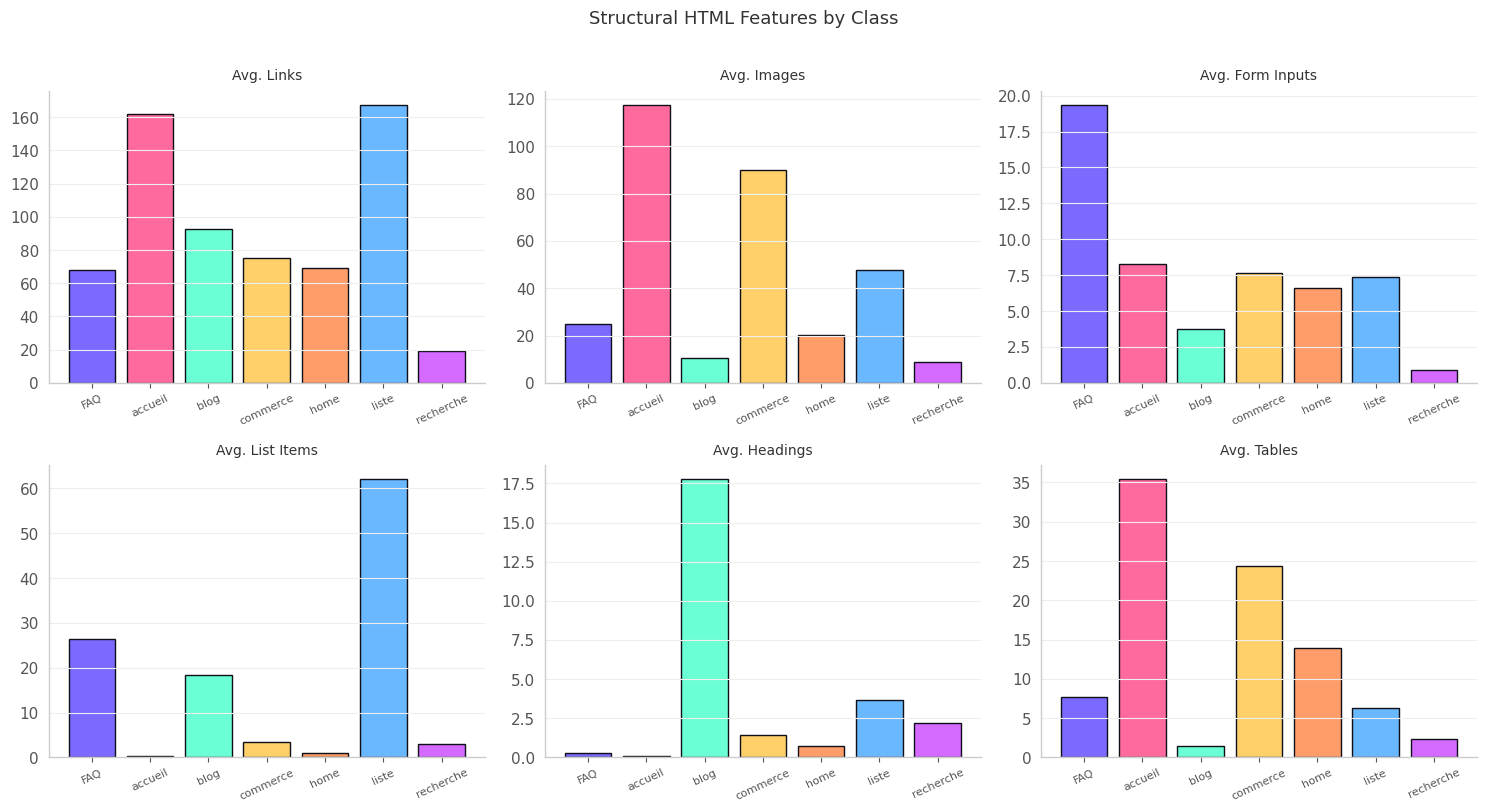

In [20]:
struct_feats = ['n_links','n_imgs','n_inputs','n_list_items','n_headings','n_tables']
feat_labels  = ['Links','Images','Form Inputs','List Items','Headings','Tables']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (feat, lbl) in enumerate(zip(struct_feats, feat_labels)):
    means = [train_df[train_df['label']==c][feat].mean() for c in CLASSES]
    axes[i].bar(CLASSES, means, color=PALETTE, edgecolor='#0f0f1a', linewidth=1)
    axes[i].set_title(f'Avg. {lbl}', fontsize=10, pad=8)
    axes[i].tick_params(axis='x', rotation=25, labelsize=8)

plt.suptitle('Structural HTML Features by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_struct_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Correlation Analysis


**Observations**:
- Word number and text length have perfect correlation, they carry identical predictive signals for the model.
- n_imgs and n_links share the strongest non-perfect correlation (0.49). This combination can suggest visual catalogs, e-commerce product grids, or gallery pages.
- n_tables correlates positively with n_forms (0.39) and n_imgs (0.32).
- There is a slight negative correlation between n_tables and n_headings (-0.23).

**Consideration**:
- n_words and text_len carry identical predictive signals for the model so one should be discarded.

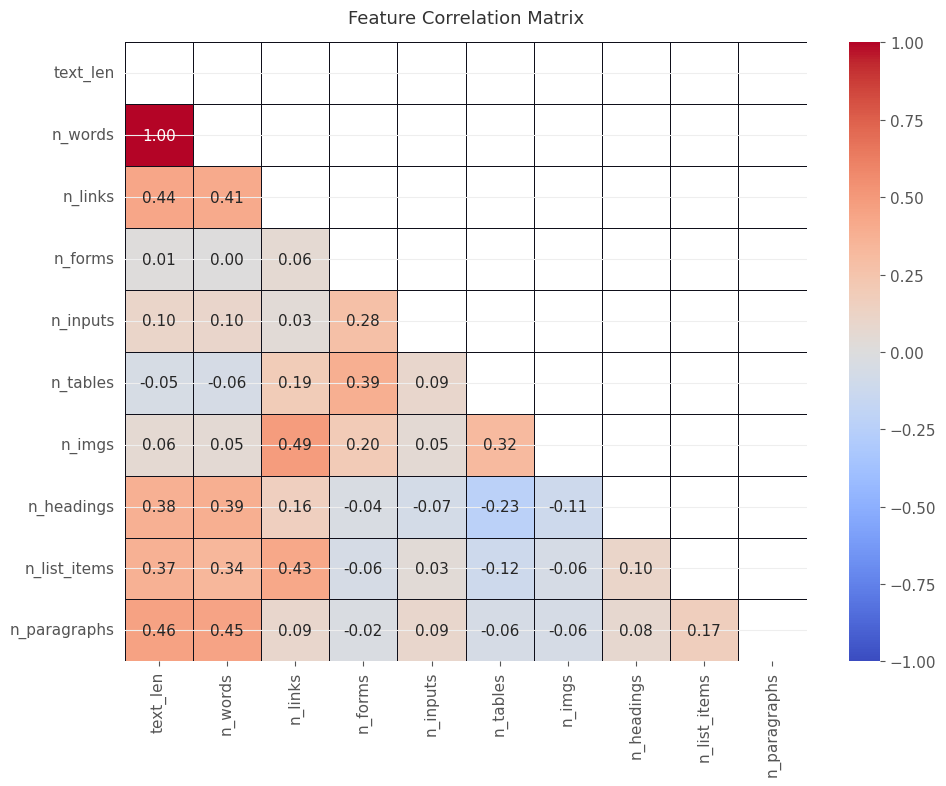

In [28]:
num_cols = ['text_len','n_words','n_links','n_forms','n_inputs','n_tables','n_imgs','n_headings','n_list_items','n_paragraphs']
corr = train_df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#0f0f1a', ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top Vocabulary per Class

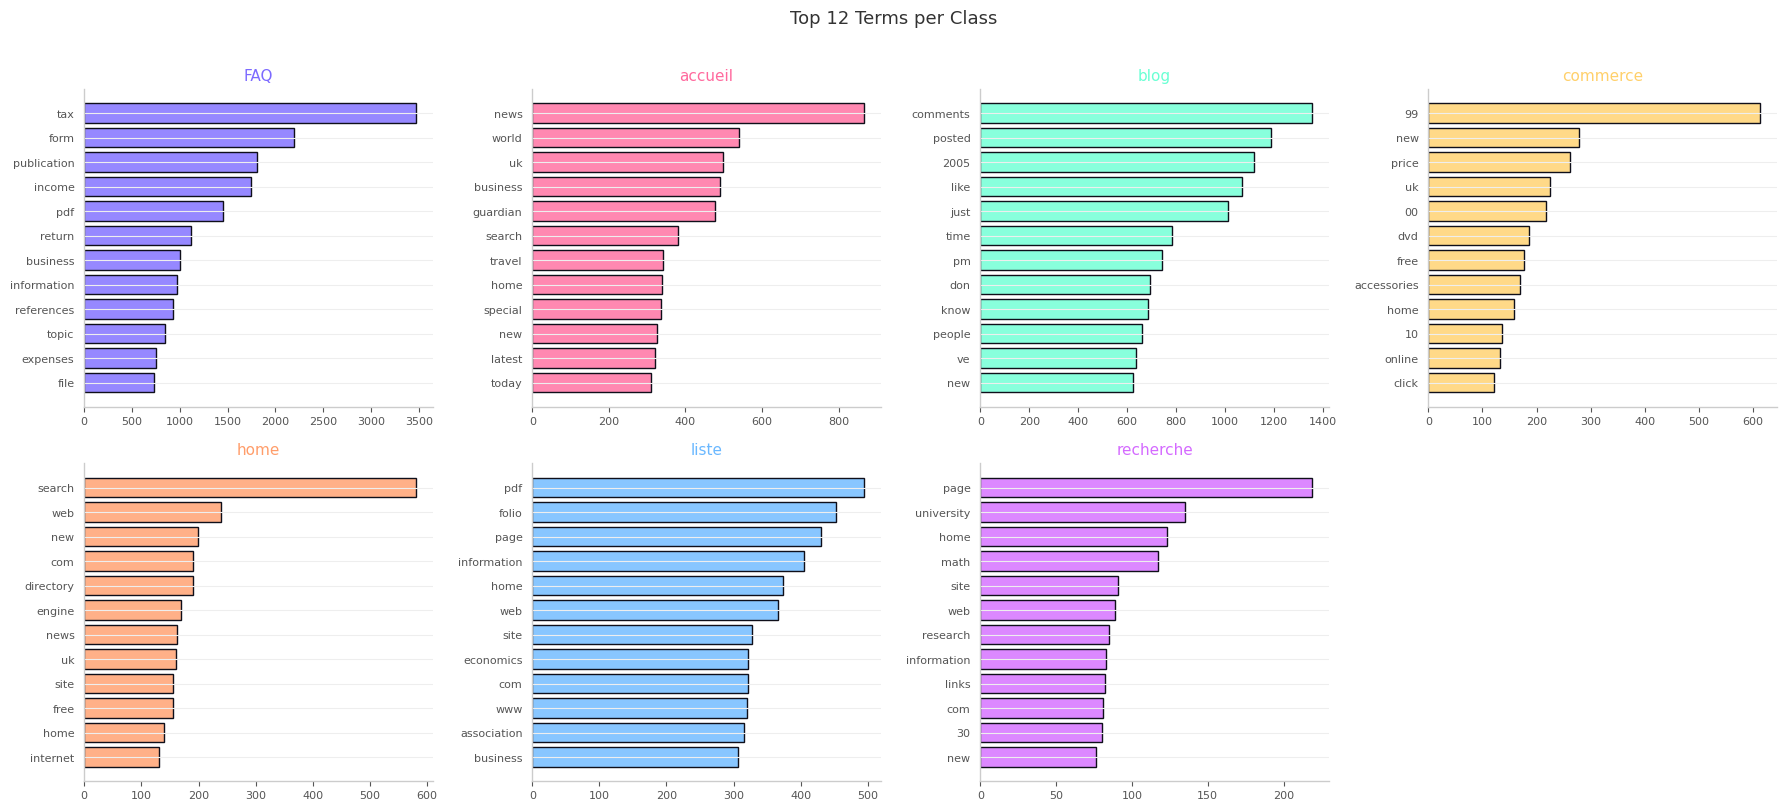

In [31]:
cv = CountVectorizer(max_features=5000, stop_words='english', min_df=2)
cv.fit(train_df['text'])
vocab = cv.get_feature_names_out()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, (cls, color) in enumerate(zip(CLASSES, PALETTE)):
    texts  = train_df[train_df['label']==cls]['text'].tolist()
    counts = cv.transform(texts).toarray().sum(axis=0)
    top_idx = counts.argsort()[::-1][:12]
    axes[i].barh([vocab[j] for j in top_idx][::-1], [counts[j] for j in top_idx][::-1],
                  color=color+'cc', edgecolor='#0f0f1a')
    axes[i].set_title(cls, fontsize=11, color=color, pad=6)
    axes[i].tick_params(labelsize=8)
axes[-1].set_visible(False)
plt.suptitle('Top 12 Terms per Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Processed Data

In [32]:
train_df.drop(columns=['text'], errors='ignore').to_csv(f'{OUT_DIR}/train_features.csv', index=False)
test_df.drop(columns=['text'],  errors='ignore').to_csv(f'{OUT_DIR}/test_features.csv',  index=False)
train_df[['label','text','file']].to_parquet(f'{OUT_DIR}/train_texts.parquet', index=False)
test_df[['label','text','file']].to_parquet(f'{OUT_DIR}/test_texts.parquet',   index=False)
print('All files saved to', OUT_DIR)

All files saved to ../data


## Summary

| Finding | Detail | Strategic Impact                                                 |
| :--- | :--- |:-----------------------------------------------------------------|
| **Balance** | 120 train / 30 test per class | Perfect split. No need for class weighting during training.      |
| **Content Volume** | `FAQ` and `blog` dominate text length. | Strong baseline separator for narrative versus functional pages. |
| **Interactive Elements** | `commerce` and `recherche` have the most inputs. | Clear indicators for transactional or search-driven layouts.     |
| **List Density** | `liste` contains the most list items. | Direct structural signature for directory or index pages.        |

Next step : Feature engineering (TF-IDF, LSA, structural normalization)